<a href="https://colab.research.google.com/github/isabelamoreiramendes29/CursoIA/blob/main/Aula_1_Fundamentos_de_IA_%2B_Ambiente_%2B_Git.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 1 - Fundamentos básicos

## Objetivos da aula:
 - Entender o que é IA, ML e DL
 - Diferenciar aprendizado supervisionado e não supervisionado
 - Conhecer aplicações de IA
 - Entender o que é um ambiente virtual
 - Aprender Git e Github

## O que é inteligencia artificial?
 No caso, falando de computação e IA estamos nos referindo ao desenvolvimento de sistemas capazes de:
  - Aprender com dados
  - Indentificar padrões
  - Tomar decisões automaticamente

**IA não é robo**

**IA é a junção de matemática + dados + computação**

## Aprendizado supervisionado x não supervisionado
**Aprendizado Supervisionado**

O aprendizado supervisionado ocorre quando treinamos o modelo utilizando um dataset que já possui as respostas corretas (rótulos).

Ou seja:

- Para cada entrada **X**, sabemos qual é a saída **y** esperada.
- O modelo aprende uma função:

\[
f(X) -\> y
\]

- Ele ajusta seus parâmetros comparando a previsão com o valor real.
- O objetivo é prever corretamente novos dados nunca vistos.
 classificações atraves dele.

 Exemplos de Aprendizado Supervisionado:

- Prever o preço de uma casa
- Classificar e-mails como spam ou não
- Detectar fraudes bancárias
- Reconhecer imagens com rótulos conhecidos

👉 Aqui existe um “professor” corrigindo o modelo durante o treino.



**Aprendizado não supervisionado :**
Aprendizado Não Supervisionado

O aprendizado não supervisionado ocorre quando o dataset **não possui rótulos (y)**.

Nesse caso:

- Temos apenas os dados **X**
- O modelo tenta encontrar **padrões, estruturas ou agrupamentos**
- Não existe resposta correta previamente definida
- O modelo "explora" os dados sozinho

Exemplos de Aprendizado Não Supervisionado

- Agrupar clientes com comportamentos semelhantes
- Sistemas de recomendação (descobrir perfis parecidos)
- Detectar anomalias em redes ou sensores
- Segmentação de mercado

👉 Aqui não existe gabarito. O modelo precisa descobrir a organização dos dados.




### ✔ Diferença Principal

| Característica | Supervisionado | Não Supervisionado |
|----------------|----------------|---------------------|
Tem rótulo (y)? | ✅ Sim | ❌ Não |
Existe resposta correta? | ✅ Sim | ❌ Não |
Objetivo | Prever | Descobrir padrões |
Exemplo | Classificação | Agrupamento |


### Aprendizado supervisionado


In [ ]:
# ============================================================
# 🌸 EXEMPLO DE CLASSIFICAÇÃO COM O DATASET IRIS
# ============================================================

# 1️⃣ Importando as bibliotecas necessárias
from sklearn.datasets import load_iris              # Dataset clássico de flores
from sklearn.model_selection import train_test_split # Separar treino e teste
from sklearn.tree import DecisionTreeClassifier      # Modelo de Árvore de Decisão
from sklearn.metrics import accuracy_score           # Avaliar desempenho


# 2️⃣ Carregando o dataset
dados = load_iris()

X = dados.data    # Características das flores (medidas)
y = dados.target  # Espécie da flor (rótulo)

# Nome das características
print("Características medidas:")
print(dados.feature_names)

# Nome das espécies possíveis
print("\nEspécies possíveis:")
print(dados.target_names)


# 3️⃣ Visualizando alguns exemplos
print("\nExemplo de 5 flores (entradas):")
print(X[:5])

print("\nClasse real dessas flores:")
print(y[:5])


# 4️⃣ Separando dados de TREINO e TESTE
# O modelo aprende com treino e é avaliado com teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% para teste
    random_state=42     # Reprodutibilidade
)


# 5️⃣ Criando o modelo de Machine Learning
model = DecisionTreeClassifier()


# 6️⃣ Treinando o modelo (fase de aprendizado)
model.fit(X_train, y_train)


# 7️⃣ Fazendo previsões com dados nunca vistos
y_pred = model.predict(X_test)


# 8️⃣ Avaliando o desempenho do modelo
accuracy = accuracy_score(y_test, y_pred)

print("\nPrevisões do modelo:")
print(y_pred[:5])

print(f"\nAcurácia do modelo: {accuracy:.2f}")


Características medidas:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Espécies possíveis:
['setosa' 'versicolor' 'virginica']

Exemplo de 5 flores (entradas):
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

Classe real dessas flores:
[0 0 0 0 0]

Previsões do modelo:
[1 0 2 1 1]

Acurácia do modelo: 1.00


### Aprendizado nao supervisionado

Agrupar as flores sem saber quem são


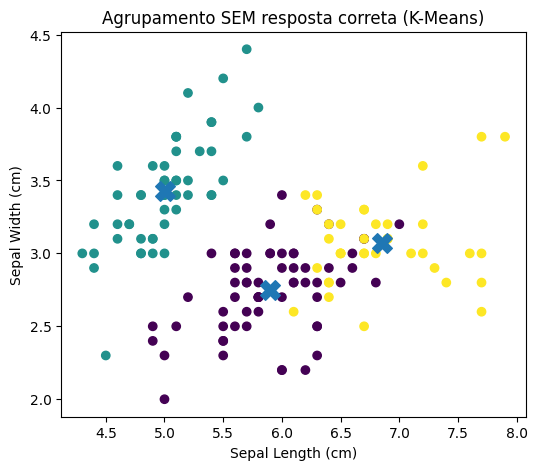

In [ ]:
# ============================================================
# EXEMPLO DE CLUSTERIZAÇÃO COM K-MEANS (SEM USAR OS RÓTULOS)
# ============================================================

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1) Carregar o dataset (mas NÃO vamos usar os rótulos)
dados = load_iris()
X = dados.data  # Apenas as características das flores

# 2) Criar o modelo K-Means
# n_clusters=3 porque sabemos que existem 3 tipos de flor
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# 3) Treinar o modelo e descobrir os grupos automaticamente
clusters = kmeans.fit_predict(X)

# 4) Visualizar os agrupamentos
# Vamos usar apenas 2 dimensões para conseguir desenhar (sepal length vs sepal width)
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=clusters)

# 5) Mostrar os centróides (o "centro" de cada grupo encontrado)
centroides = kmeans.cluster_centers_
plt.scatter(centroides[:, 0], centroides[:, 1], marker='X', s=200)

# 6) Melhorar o gráfico
plt.title("Agrupamento SEM resposta correta (K-Means)")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")

plt.show()


## Diferença entre Machine Learning e Deep Learning

**Machine Learning (ML)**  
→ Conjunto de algoritmos que aprendem padrões a partir dos dados.  
→ Normalmente exige que o ser humano escolha quais características são importantes.  
→ Funciona bem com datasets menores e problemas mais simples.

**Deep Learning (DL)**  
→ É um subcampo do Machine Learning baseado em **Redes Neurais Profundas**.  
→ O próprio modelo aprende automaticamente quais características são relevantes.  
→ Precisa de mais dados, mais processamento e é usado em problemas complexos como visão computacional, voz e linguagem natural.

---

### O que vamos fazer agora?

Vamos comparar ML e DL **na prática**, usando o dataset **Iris**:

- É um dataset pequeno e clássico.
- É um problema **supervisionado** (sabemos a resposta correta).
- Ideal para entender a diferença de abordagem entre os dois métodos.

👉 Primeiro vamos resolver com **Machine Learning tradicional**.  
👉 Depois vamos resolver com **Deep Learning** e comparar os resultados.


In [5]:
# ============================================================
# 1) MACHINE LEARNING (ML) - ÁRVORE DE DECISÃO (scikit-learn)
# ============================================================

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1) Carregar o dataset
dados = load_iris()
X = dados.data          # Features (medidas)
y = dados.target        # Labels (espécies: 0,1,2)

# 2) Separar treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3) Criar e treinar o modelo
model_ml = DecisionTreeClassifier(random_state=42)
model_ml.fit(X_train, y_train)

# 4) Prever e avaliar
y_pred_ml = model_ml.predict(X_test)
acc_ml = accuracy_score(y_test, y_pred_ml)

print("=== ML (Decision Tree) ===")
print("Acurácia:", round(acc_ml, 4))
print("Exemplo de previsões:", y_pred_ml[:10])


=== ML (Decision Tree) ===
Acurácia: 1.0
Exemplo de previsões: [1 0 2 1 1 0 1 2 1 1]


In [ ]:
# ============================================================
# 2) DEEP LEARNING (DL) - REDE NEURAL (TensorFlow / Keras)
# ============================================================

import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# 1) Carregar o dataset
dados = load_iris()
X = dados.data
y = dados.target

# 2) Normalizar as features (boa prática para redes neurais)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 3) One-hot encoding dos rótulos (0,1,2 -> [1,0,0], [0,1,0], [0,0,1])
y_cat = to_categorical(y, num_classes=3)

# 4) Separar treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42
)

# 5) Criar o modelo
model_dl = Sequential([
    Dense(16, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(16, activation="relu"),
    Dense(3, activation="softmax")  # 3 classes
])

# 6) Compilar o modelo
model_dl.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# 7) Treinar
model_dl.fit(X_train, y_train, epochs=50, batch_size=16, verbose=0)

# 8) Avaliar
loss, acc_dl = model_dl.evaluate(X_test, y_test, verbose=0)

# 9) Previsões (convertendo de probabilidade para classe)
y_pred_dl = model_dl.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred_dl, axis=1)

print("\n=== DL (Neural Network) ===")
print("Acurácia:", round(acc_dl, 4))
print("Exemplo de previsões:", y_pred_classes[:10])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



=== DL (Neural Network) ===
Acurácia: 1.0
Exemplo de previsões: [1 0 2 1 1 0 1 2 1 1]


## Inteligencia computacional

Além de Ml de DL, existem outras abordadgens dentro da inteligencia artificial que são muito uteis para problemas específicos. Vamos explorar algumas delas, que são : Logica fuzzy e algoritmo genético


### O que é inteligencia computacional?
É um ramo da IA que busca desenvolver sistemas inspirados na natureza e na capacidade de lidar com incertezas e tomar decisoes. Ela engloba técnicas como :
- **Lógica Fuzzy (Nebulosa)**: Lida com conceitos imprecisos como "muito quente" ou "um pouco frio"
- **Algoritmos Genéticos**: Inspirados na evolução das espécies (seleção natural)
- **Redes Neurais Artificiais** (já vimos em Deep Learning)
- **Sistemas Imunológicos Artificiais**

## 1. Lógica Fuzzy (Lógica Nebulosa)

### Conceito

Diferente da lógica tradicional (booleana), onde algo é verdadeiro (1) ou falso (0), a lógica fuzzy permite **graus de pertinência** entre 0 e 1.

 **Exemplo**:
- Lógica tradicional: "Está quente?" → Sim (1) ou Não (0)
- Lógica fuzzy: "Está quente?" → 0.7 (relativamente quente)

### Componentes principais:
1. **Variáveis linguísticas** (ex: temperatura, velocidade)
2. **Conjuntos fuzzy** (ex: frio, morno, quente)
3. **Regras fuzzy** (SE... ENTÃO...)
4. **Fuzzificação e Defuzzificação**

In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1) Carregar dados
dados = load_iris()
X = dados.data
y = dados.target

# Vamos simplificar: classificar apenas Setosa (0) vs Não-Setosa (1,2)
y_bin = (y == 0).astype(int)  # 1 se for Setosa, 0 caso contrário

# 2) Criar variáveis fuzzy
# Antecedentes (features)
sepal_length = ctrl.Antecedent(np.arange(4, 8, 0.1), 'sepal_length')
sepal_width = ctrl.Antecedent(np.arange(2, 5, 0.1), 'sepal_width')
petal_length = ctrl.Antecedent(np.arange(1, 7, 0.1), 'petal_length')
petal_width = ctrl.Antecedent(np.arange(0, 3, 0.1), 'petal_width')

# Consequente (classe)
classe = ctrl.Consequent(np.arange(0, 1.1, 0.1), 'classe')

# 3) Definir funções de pertinência
# Para Setosa: pétala curta e sépala característica
petal_length['curta'] = fuzz.trimf(petal_length.universe, [1, 1.5, 2.5])
petal_length['longa'] = fuzz.trimf(petal_length.universe, [2.5, 5, 7])

petal_width['estreita'] = fuzz.trimf(petal_width.universe, [0, 0.2, 0.6])
petal_width['larga'] = fuzz.trimf(petal_width.universe, [0.6, 2, 3])

# Classe: 0 = Não-Setosa, 1 = Setosa
classe['nao_setosa'] = fuzz.trimf(classe.universe, [0, 0, 0.5])
classe['setosa'] = fuzz.trimf(classe.universe, [0.5, 1, 1])

# 4) Criar regras fuzzy
regra1 = ctrl.Rule(
    petal_length['curta'] & petal_width['estreita'],
    classe['setosa']
)
regra2 = ctrl.Rule(
    petal_length['longa'] | petal_width['larga'],
    classe['nao_setosa']
)

# 5) Criar sistema de controle
sistema_ctrl = ctrl.ControlSystem([regra1, regra2])
sistema = ctrl.ControlSystemSimulation(sistema_ctrl)

# 6) Testar com algumas amostras
X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.3, random_state=42
)

predicoes = []
for i in range(len(X_test)):
    sistema.input['sepal_length'] = X_test[i, 0]
    sistema.input['sepal_width'] = X_test[i, 1]
    sistema.input['petal_length'] = X_test[i, 2]
    sistema.input['petal_width'] = X_test[i, 3]

    try:
        sistema.compute()
        pred = 1 if sistema.output['classe'] > 0.5 else 0
    except:
        pred = 0
    predicoes.append(pred)

acuracia = accuracy_score(y_test, predicoes)
print("=== LÓGICA FUZZY ===")
print(f"Acurácia (Setosa vs Não-Setosa): {acuracia:.2f}")
print(f"Previsões: {predicoes[:10]}")
print(f"Valores reais: {y_test[:10]}")

## Algoritmos Genéticos

### Conceito

Algoritmos Genéticos são inspirados na **evolução natural** (Darwinismo). Eles evoluem soluções para um problema através de:

1. **População**: Conjunto de soluções candidatas
2. **Seleção**: Escolha dos melhores indivíduos
3. **Cruzamento (Crossover)**: Combinação de soluções
4. **Mutação**: Pequenas alterações aleatórias
5. **Aptidão (Fitness)**: Função que avalia quão boa é cada solução

### Aplicações em IA:
- Otimização de hiperparâmetros
- Seleção de features
- Treinamento de redes neurais
- Problemas de roteamento
- Otimização de funções matemáticas

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# 1) Carregar e preparar os dados
print("=" * 60)
print("ALGORITMO GENÉTICO PARA CLASSIFICAÇÃO IRIS")
print("=" * 60)

dados = load_iris()
X = dados.data
y = dados.target

# Normalizar os dados (importante para pesos funcionarem bem)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Separar treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n📊 Dados carregados:")
print(f"   - Features: {X.shape[1]} (comprimento e largura das sépalas e pétalas)")
print(f"   - Classes: {dados.target_names}")
print(f"   - Amostras de treino: {X_train.shape[0]}")
print(f"   - Amostras de teste: {X_test.shape[0]}")

# 2) Parâmetros do algoritmo genético
POP_SIZE = 50          # Tamanho da população
GERACOES = 40          # Número de gerações
TAXA_MUTACAO = 0.1     # Probabilidade de mutação
TAXA_CRUZAMENTO = 0.8  # Probabilidade de cruzamento
N_FEATURES = X.shape[1]  # 4 features
N_CLASSES = 3          # 3 classes

print(f"\n🧬 Parâmetros do Algoritmo Genético:")
print(f"   - População: {POP_SIZE} indivíduos")
print(f"   - Gerações: {GERACOES}")
print(f"   - Taxa de mutação: {TAXA_MUTACAO}")
print(f"   - Taxa de cruzamento: {TAXA_CRUZAMENTO}")

# 3) Função de fitness: avalia um conjunto de pesos
def fitness(individuo):
    """
    Indivíduo é uma matriz de pesos [N_CLASSES x N_FEATURES]
    Calcula a acurácia usando regra: classe = argmax(X @ pesos.T)
    """
    pesos = individuo.reshape(N_CLASSES, N_FEATURES)
    scores = X_train @ pesos.T
    predicoes = np.argmax(scores, axis=1)
    return accuracy_score(y_train, predicoes)

# 4) Criar população inicial
def criar_populacao():
    populacao = []
    for i in range(POP_SIZE):
        # Pesos aleatórios entre -1 e 1
        individuo = np.random.uniform(-1, 1, N_CLASSES * N_FEATURES)
        populacao.append(individuo)
    return np.array(populacao)

print("\n🌱 Criando população inicial...")
populacao = criar_populacao()

# 5) Seleção por torneio
def selecao_torneio(populacao, fitness_scores, tamanho_torneio=3):
    """Seleciona o melhor indivíduo de um torneio aleatório"""
    indices = np.random.choice(len(populacao), tamanho_torneio, replace=False)
    vencedor = indices[np.argmax(fitness_scores[indices])]
    return populacao[vencedor].copy()

# 6) Cruzamento (crossover)
def cruzamento(pai1, pai2):
    """Realiza crossover em um ponto"""
    if np.random.random() < TAXA_CRUZAMENTO:
        ponto = np.random.randint(1, len(pai1) - 1)
        filho1 = np.concatenate([pai1[:ponto], pai2[ponto:]])
        filho2 = np.concatenate([pai2[:ponto], pai1[ponto:]])
        return filho1, filho2
    else:
        return pai1.copy(), pai2.copy()

# 7) Mutação
def mutacao(individuo):
    """Aplica mutação gaussiana"""
    for i in range(len(individuo)):
        if np.random.random() < TAXA_MUTACAO:
            individuo[i] += np.random.normal(0, 0.2)  # Pequena alteração
    return individuo

# 8) Executar algoritmo genético
print("\n🚀 Iniciando evolução...")
print("-" * 60)
print("Geração | Melhor Fitness | Fitness Médio | Pior Fitness")
print("-" * 60)

melhor_fitness_historico = []
fitness_medio_historico = []
pior_fitness_historico = []

for geracao in range(GERACOES):
    # Avaliar fitness de toda a população
    fitness_scores = np.array([fitness(ind) for ind in populacao])

    # Estatísticas da geração
    melhor_fitness = np.max(fitness_scores)
    fitness_medio = np.mean(fitness_scores)
    pior_fitness = np.min(fitness_scores)

    melhor_fitness_historico.append(melhor_fitness)
    fitness_medio_historico.append(fitness_medio)
    pior_fitness_historico.append(pior_fitness)

    # Mostrar progresso a cada 5 gerações
    if geracao % 5 == 0:
        print(f"   {geracao:3d}   |     {melhor_fitness:.4f}    |    {fitness_medio:.4f}    |   {pior_fitness:.4f}")

    # Elitismo: manter os 2 melhores indivíduos
    melhores_indices = np.argsort(fitness_scores)[-2:]
    elite = [populacao[i].copy() for i in melhores_indices]

    # Criar nova população
    nova_populacao = []

    # Adicionar elite
    nova_populacao.extend(elite)

    # Gerar resto da população
    while len(nova_populacao) < POP_SIZE:
        # Selecionar pais
        pai1 = selecao_torneio(populacao, fitness_scores)
        pai2 = selecao_torneio(populacao, fitness_scores)

        # Cruzamento
        filho1, filho2 = cruzamento(pai1, pai2)

        # Mutação
        filho1 = mutacao(filho1)
        filho2 = mutacao(filho2)

        nova_populacao.extend([filho1, filho2])

    # Atualizar população (manter tamanho POP_SIZE)
    populacao = np.array(nova_populacao[:POP_SIZE])

print("-" * 60)
print(f"   {GERACOES:3d}   |     {melhor_fitness:.4f}    |    {fitness_medio:.4f}    |   {pior_fitness:.4f}")
print("-" * 60)

# 9) Avaliar no conjunto de teste
print("\n📝 Avaliando melhor indivíduo no conjunto de teste...")

# Encontrar o melhor indivíduo da última geração
fitness_scores_final = np.array([fitness(ind) for ind in populacao])
melhor_indice = np.argmax(fitness_scores_final)
melhor_individuo = populacao[melhor_indice]
melhores_pesos = melhor_individuo.reshape(N_CLASSES, N_FEATURES)

# Função para testar
def testar_individuo(individuo, X, y):
    pesos = individuo.reshape(N_CLASSES, N_FEATURES)
    scores = X @ pesos.T
    predicoes = np.argmax(scores, axis=1)
    return accuracy_score(y, predicoes)

# Avaliar no treino e teste
acuracia_treino = testar_individuo(melhor_individuo, X_train, y_train)
acuracia_teste = testar_individuo(melhor_individuo, X_test, y_test)

print(f"\n✅ Resultados finais:")
print(f"   - Acurácia no treino: {acuracia_treino:.4f}")
print(f"   - Acurácia no teste: {acuracia_teste:.4f}")

# 10) Fazer previsões
scores_teste = X_test @ melhores_pesos.T
predicoes_teste = np.argmax(scores_teste, axis=1)

print(f"\n🔍 Exemplo de previsões (primeiras 10 amostras):")
print(f"   Previsto:  {predicoes_teste[:10]}")
print(f"   Real:      {y_test[:10]}")
print(f"   Espécies:  {dados.target_names[predicoes_teste[:10]]}")

# 11) Visualizar a evolução
plt.figure(figsize=(12, 5))

# Gráfico de evolução
plt.subplot(1, 2, 1)
plt.plot(melhor_fitness_historico, 'g-', linewidth=2, label='Melhor')
plt.plot(fitness_medio_historico, 'b-', linewidth=2, label='Médio')
plt.plot(pior_fitness_historico, 'r-', linewidth=2, label='Pior')
plt.title('Evolução do Fitness - Algoritmo Genético')
plt.xlabel('Geração')
plt.ylabel('Fitness (Acurácia)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.05)

In [ ]:
# Gerar 100 indivíduos aleatórios e testar
aleatorios = [np.random.uniform(-1, 1, N_CLASSES * N_FEATURES) for _ in range(100)]
acuracia_aleatoria = np.mean([testar_individuo(ind, X_test, y_test) for ind in aleatorios])

print(f"   - AG (otimizado): {acuracia_teste:.4f}")
print(f"   - Aleatório: {acuracia_aleatoria:.4f}")
print(f"   - Melhoria: {(acuracia_teste - acuracia_aleatoria)*100:.1f}%")

## Preparando o Ambiente

Antes de começar a programar, precisamos entender **o que é um ambiente virtual (venv)** e por que ele é importante.

### O que é um ambiente virtual?

Um **ambiente virtual** é como se fosse uma **“caixinha isolada” dentro do seu computador**, onde você instala apenas as bibliotecas que aquele projeto precisa.

Ele serve para:

- Evitar conflitos entre versões de bibliotecas  
- Permitir que cada projeto tenha suas próprias dependências  
- Manter o sistema operacional “limpo”  
- Garantir que o código funcione igual em qualquer máquina  
- Reproduzir experimentos de forma confiável (muito importante em IA)

📌 Exemplo de problema sem ambiente virtual:

Você instala:
- Projeto A precisa do `numpy==1.21`
- Projeto B precisa do `numpy==2.0`

➡️ Sem isolamento, um quebra o outro.

Com ambiente virtual:
- Cada projeto usa sua própria versão → tudo funciona.

---

## Diferença entre usar Google Colab e VSCode

###  Google Colab

No **Colab você NÃO precisa criar ambiente virtual**, porque:

- Cada notebook já roda em um ambiente isolado na nuvem
- Quando você fecha o runtime, ele é destruído
- Cada execução começa “do zero”

Ou seja, o Colab já faz automaticamente o que o `venv` faria localmente.

👉 No Colab você só instala o que precisar com:


### Vscode :
Para aqueles que estao rodando no vs precisamos seguir alguns comandos, dentro do terminal (ja dentro da pasta do projeto)

1º) Criação do venv : python/python3 -m venv ia_env

2º) Ativação do venv:
  - Windows : ia_env\Scripts\activate
  - Mac/Linux : source ia_env/bin/activate

3º) Instalação das bibliotecas

4º) Exportação das bibliotecas (requirements.txt)

In [ ]:
""""
Agora vamos ver um exemplo da aplicação do venv. No caso, nao vamos especificar uma determinada versao da biblioteca
isso pode gerar conflito, pois o outro pdoe instalar uma versao que nao estamos usando.
"""""
#Instalação das biblitoecas sem especificar versão
!pip install scikit_learn matplotlib pandas numpy

In [ ]:
# Salvando todas as bibliotecas instaladas no ambiente atual
!pip freeze > requirements.txt

# Verificando se o arquivo foi criado
!ls -lh requirements.txt

print("Arquivo requirements.txt salvo em: /content/requirements.txt")


-rw-r--r-- 1 root root 15K Feb 12 14:24 requirements.txt
Arquivo requirements.txt salvo em: /content/requirements.txt


Agora quando outra pessoa for rodar nosso codigo, encaminhamos o arquivo requirements e ela poderá baixar as mesmas versoes em seu ambiente. Evitando grandes erros.


## Git X Github
### O que é o GitHub?

O **GitHub** é uma plataforma para **armazenar, versionar e compartilhar código**.

Ele funciona junto com o **Git**, que é um sistema de controle de versão.

📌 Pense assim:

> Git = ferramenta que controla versões do código  
> GitHub = lugar na internet onde você salva e compartilha esse código

---

## Por que usamos GitHub em projetos de IA?

Em projetos de Machine Learning e Data Science precisamos:

- Guardar versões do experimento (não perder código antigo)
- Trabalhar em equipe
- Compartilhar projetos
- Reproduzir resultados
- Ter histórico do que foi alterado
- Criar portfólio profissional

---

## O que é Controle de Versão?

Controle de versão é como um **histórico de alterações**, mas para código.

Você consegue:

✔ Voltar para versões antigas  
✔ Ver o que mudou  
✔ Saber quem mudou  
✔ Testar sem quebrar o projeto  
✔ Trabalhar em paralelo com outras pessoas  

---




Vamos começar com controle de versão!

1º) Crie uma conta no github (quem ja tem uma conta, pode utiliza-la)
https://github.com/?locale=pt-BR

**Usuarios do vscode:**
1.2) Instalar o git no computador (Me chame em caso de duvidas)

1.3) Voces podem escolher o github desktop ou o git normal (Eu acho o git desktop mais facil, logo recomendo voce usarem ele)

1.4)Entrar na pasta do projeto

1.5) Entrar com comandos no terminal :
        - git init (iniciando o git na pasta)

        - git add . ( Adicionando os arquivos que vamos subir para o git. O '.' serve para indicar todos, mas podemos entrar com o caminho/nome no arquivo e subir so ele)

        - git commit (para seu arquivo entrar na fila)
        
        - git push (subimos para o servidor do git)

**Collab :**
  O collab ja tem integração com git, logo, o processo é mais simples
1.2) Clicar em 'file' -> Save a copy on github -> Escolher o diretorio -> Clicar no ok!

Pronto, a partir dai temos o começo de um versionamento de código



### Boas práticas do git
Dentro do ambiente do git tambem temos boas práticas, e sempre que vamos commitar é importante que declaramos o que fizemos para que o outro tambem consiga entender.  Abaixo temos umas classficações de commits que deverão ser utilizadas por voces durante o curso

| Tipo | Quando usar |
|------|-------------|
feat | Nova funcionalidade |
fix | Correção de erro |
refactor | Reorganização |
docs | Documentação |
style | Formatação |
perf | Performance |
test | Testes |
chore | Manutenção |

Ex =
    - (feat): Adicionando opção de recuperação de senha
    
    - (fix) : Correção de erro de integração do banco

# Atividade proposta
## Atividade Prática — Primeiro Projeto de Machine Learning e Inteligência Computacional

Agora é hora de praticar tudo o que vimos até aqui 🚀

Vocês irão montar um **mini-projeto completo**, passando por:

- Criação do ambiente (Colab ou venv no VSCode)
- Instalação de bibliotecas
- Uso do GitHub
- Treinamento de um modelo de Machine Learning
- Implementação de Lógica Fuzzy e Algoritmo Genético (versões simples)
- Boas práticas de commit

---

## 🎯 Objetivo da Atividade

Construir um projeto de classificação utilizando o dataset **Iris** com três abordagens:

1. **Machine Learning** (Árvore de Decisão)
2. **Lógica Fuzzy** (versão simplificada)
3. **Algoritmo Genético** (versão simplificada)

Versionar tudo corretamente no GitHub seguindo boas práticas profissionais.

---

## ✅ Pontos que serão avaliados

- Organização do diretório do projeto
- Código bem comentado e corretamente identado
- Criação de um `README.md` explicando o projeto
  *(pesquisem exemplos reais!)*
- Commit inicial do projeto (mensagem clara + arquivos corretos)
- Commits para cada implementação (ML, Fuzzy e AG)
- Commit com ajustes ou melhorias no código
- Presença do arquivo `requirements.txt`

**OBS: NÃO COMMITAMOS O ARQUIVO DO AMBIENTE VIRTUAL (PARA QUEM ESTÁ NO VS)**